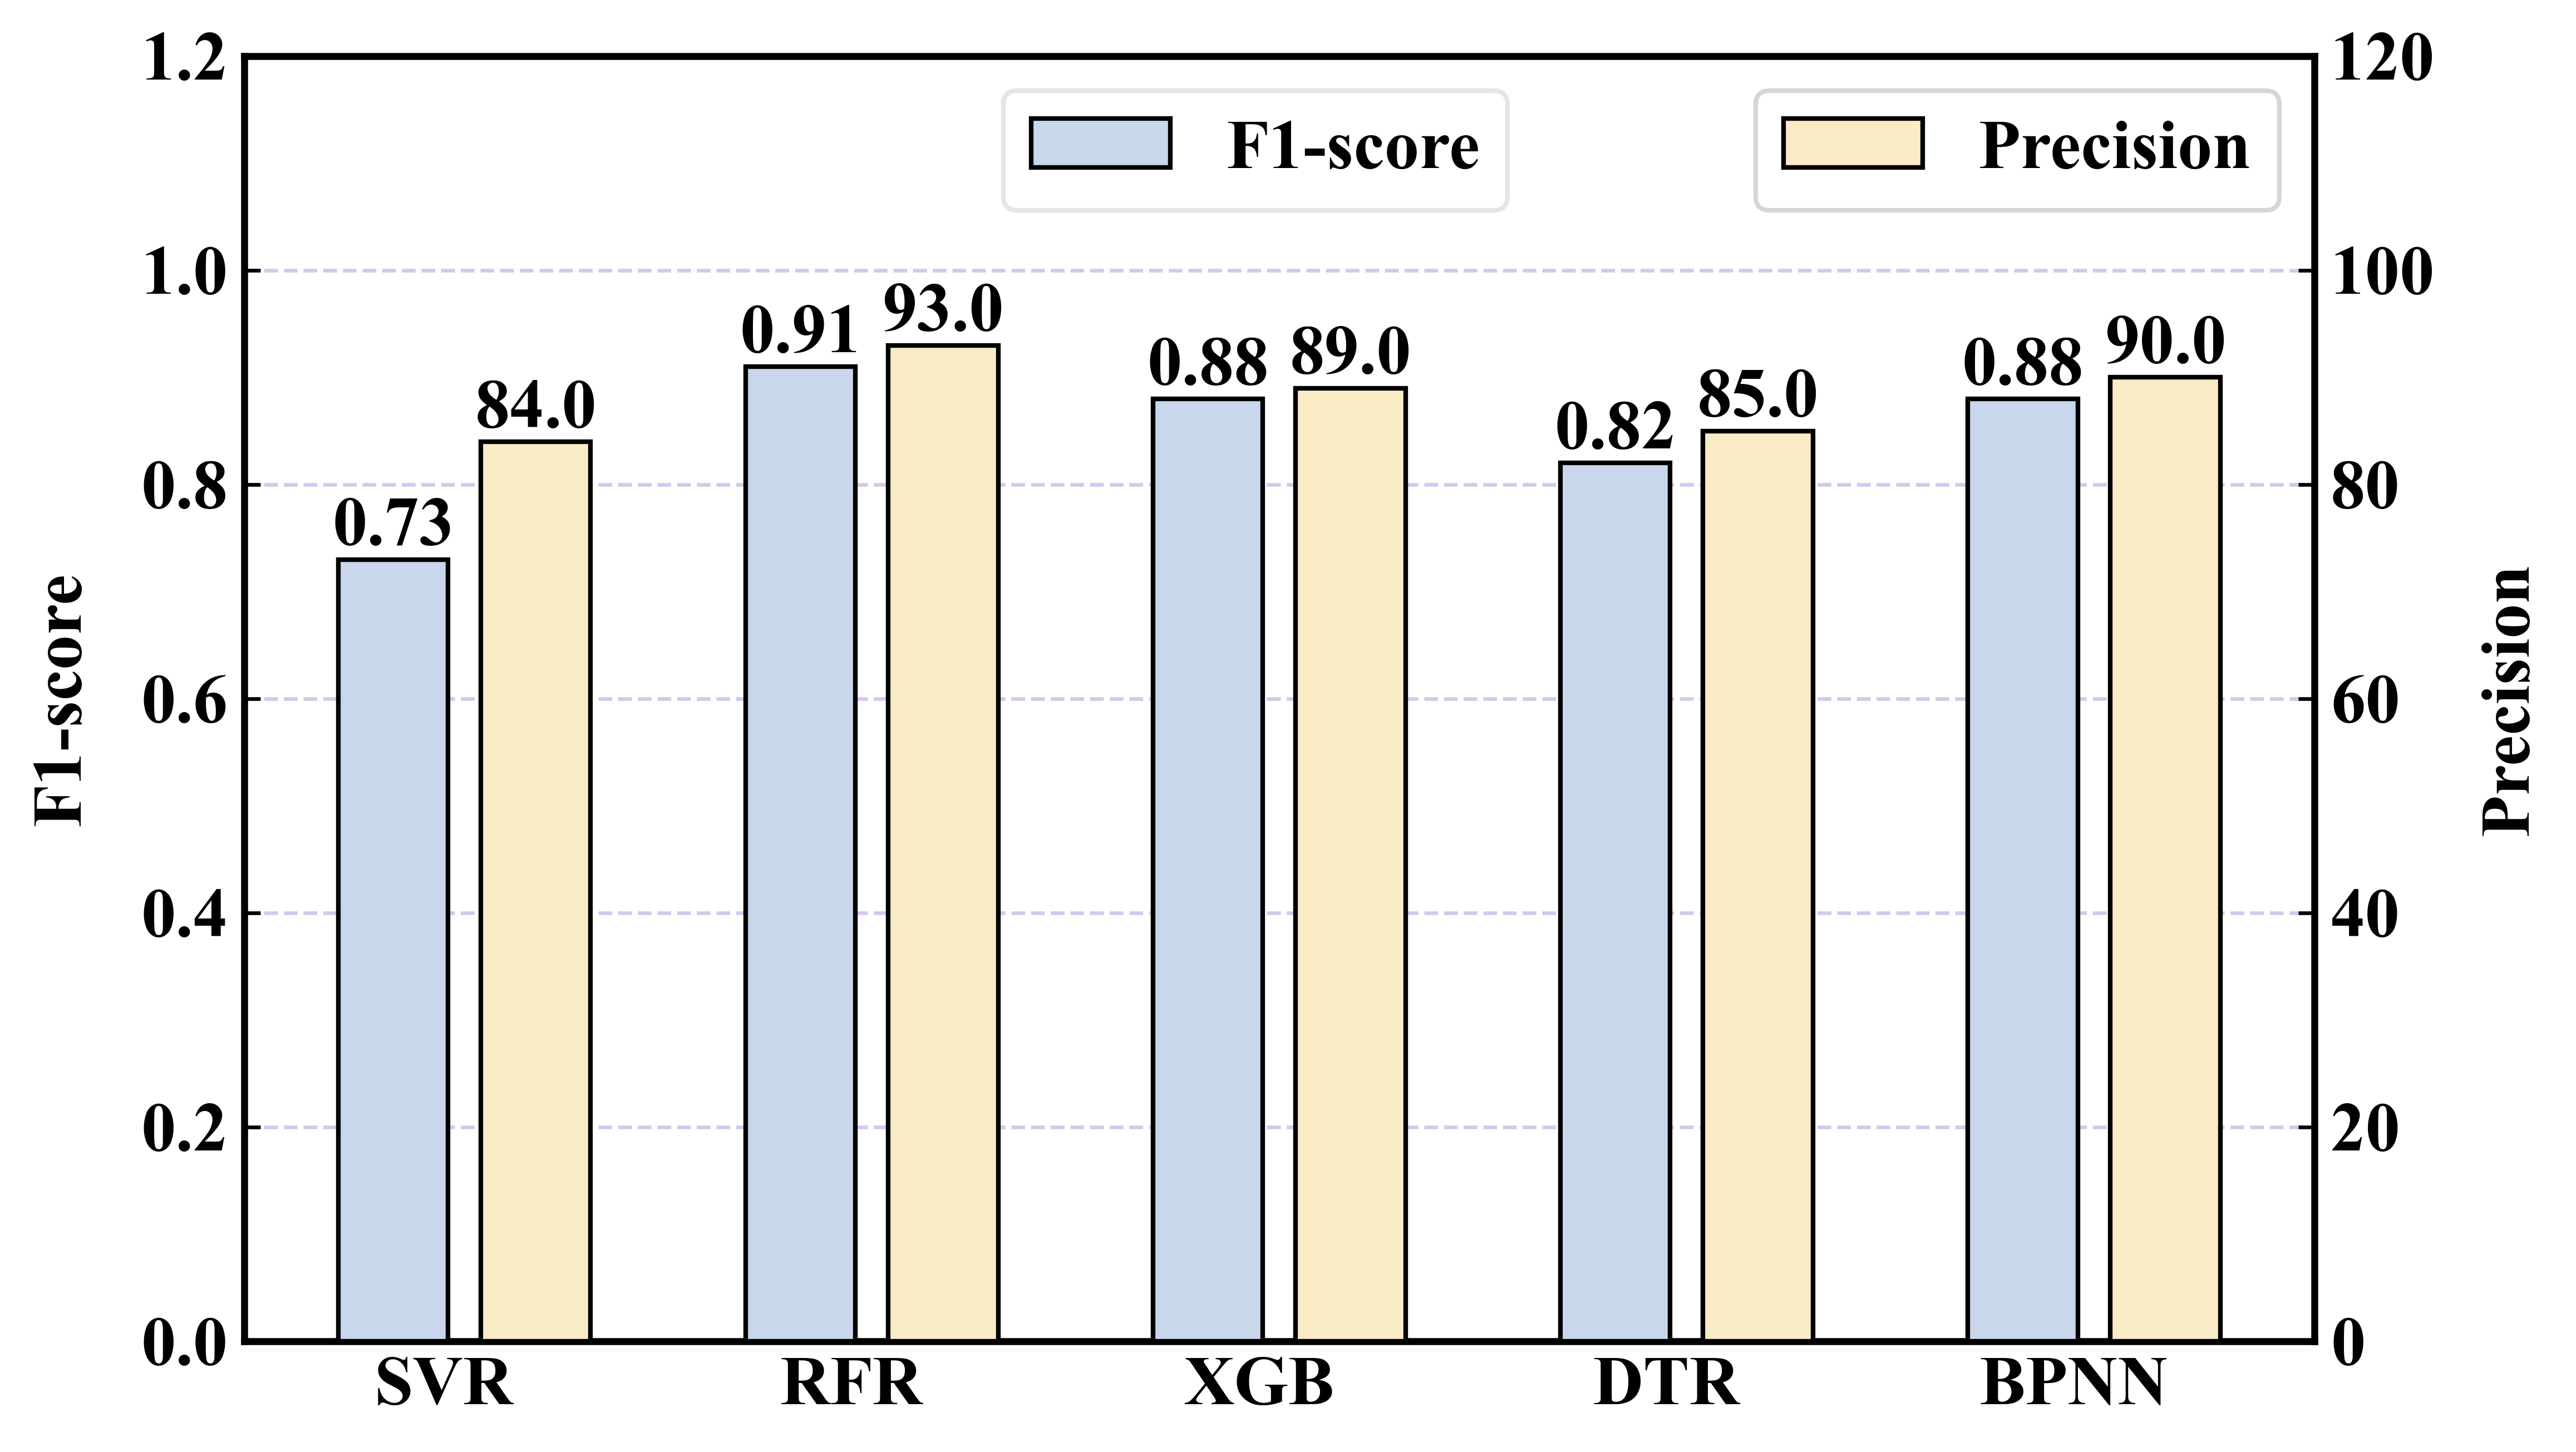

In [27]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerPatch

f1_1 = [0.73, 0.91, 0.88, 0.82, 0.88]  # R2
f1_2 = [84, 93, 89, 85, 90]  # MAPE
x = ['SVR', 'RFR', 'XGB', 'DTR', 'BPNN']
x_ticks = np.arange(len(x))
total_width, n = 0.6, 3
width = 0.35
xticks = x_ticks - (total_width - width) / 2
plt.figure(figsize=(8, 5), dpi=600)
ax = plt.axes()
plt.grid(axis="y", c='#d2c9eb', linestyle='--', zorder=0)

# 第一个柱状图的绘制
f1_1_bar = plt.bar(xticks, f1_1, width=0.77 * width, label='F1-score', color='#C8D7EB', edgecolor='#000000',
                   linewidth=1, zorder=15)
for bar in f1_1_bar:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}',
             ha='center', va='bottom', fontproperties='Times New Roman', fontsize=15, fontweight='bold')

# 第二个柱状图的绘制
ax2 = ax.twinx()
f1_2_bar = plt.bar(xticks + width, f1_2, width=0.77 * width, label='Precision', color='#FAEBC7', edgecolor='#000000',
                   linewidth=1, zorder=15)
for bar in f1_2_bar:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}',
             ha='center', va='bottom', fontproperties='Times New Roman', fontsize=15, fontweight='bold')

class HandlerBarLabel(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize):
        x = width / 5
        y = height / 5
        label = plt.Text(x, y, orig_handle,
                         fontsize=fontsize,
                         ha="center", va="center")
        return [label]

handles, labels = ax.get_legend_handles_labels()  # 添加图例
ax.legend(handles, labels, handler_map={plt.Rectangle: HandlerBarLabel()}, fancybox=True,
          framealpha=0.5, prop={'family': 'Times New Roman', 'weight': 'bold','size': 15}, ncol=2,
          bbox_to_anchor=(0.35, 1), loc='upper left')
ax2.legend(prop={'family': 'Times New Roman', 'weight': 'bold','size': 15}, ncol=2)

plt.xticks(x_ticks, x, fontproperties='Times New Roman', fontsize=15)
plt.yticks(fontproperties='Times New Roman', fontsize=15)
plt.yticks(fontproperties='Times New Roman', fontsize=15, fontweight='bold')  # 加粗显示纵坐标标签
plt.ylim(0, 120)
ax.set_ylim(0, 1.2)

for label in ax.yaxis.get_ticklabels():
    label.set_fontname('Times New Roman')
    label.set_fontsize(15)
    label.set_fontweight('bold')

ax.set_ylabel('F1-score', fontproperties='Times New Roman', fontsize=15, fontweight='bold',labelpad=10)
plt.ylabel("Precision", fontproperties='Times New Roman', fontsize=15, fontweight='bold',labelpad=10)
ax.set_xticklabels(x, fontweight='bold', fontsize=15, fontname='Times New Roman')

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax.tick_params(axis='both', direction='in')
ax2.tick_params(axis='both', direction='in')

plt.show()